# 10 — EEGNet

## Goal

Test whether an EEG-specific neural-network architecture improves
cross-subject motor-imagery classification compared with the simple
1D CNN baseline.

The experimental setup remains fixed:

- Same frozen 7–30 Hz preprocessing
- Same +1 to +4 s motor-imagery window
- Same 64 EEG channels
- Same left/right labels
- Same 76 training subjects
- Same 16 validation subjects
- Same 17 untouched test subjects
- Same primary metric: balanced accuracy

The main experimental change is the model architecture.

Baseline CNN result:
- Final training BA: 0.993
- Best validation BA: 0.528

The test set remains untouched.

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import balanced_accuracy_score

### Paths and configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("Device:", device)

Device: mps


### Load saved arrays and split

In [3]:
X = np.load(
    DATA_DIR / "X_motor_imagery.npy",
    mmap_mode="r"
)

y = np.load(
    DATA_DIR / "y_motor_imagery.npy",
    mmap_mode="r"
)

subjects = np.load(
    DATA_DIR / "subjects.npy",
    mmap_mode="r"
)

split_table = pd.read_csv(
    RESULTS_DIR / "week9_subject_split.csv"
)

train_subjects = split_table.loc[
    split_table["split"] == "train",
    "subject"
].to_numpy()

val_subjects = split_table.loc[
    split_table["split"] == "validation",
    "subject"
].to_numpy()

train_indices = np.flatnonzero(
    np.isin(subjects, train_subjects)
)

val_indices = np.flatnonzero(
    np.isin(subjects, val_subjects)
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))

Train: 3423
Validation: 718


### Function for EEGNet dataset 
Added an extra 1 for the feature-map dimension

In [4]:
class EEGNetDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = X
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        trial_index = self.indices[index]

        x = torch.tensor(
            self.X[trial_index],
            dtype=torch.float32
        ) * 1e6

        x = x.unsqueeze(0) #Insert dimension with size 1

        y = torch.tensor(
            self.y[trial_index],
            dtype=torch.long
        )

        return x, y

### Create dataset and dataloaders

In [5]:
train_dataset = EEGNetDataset(
    X,
    y,
    train_indices
)

val_dataset = EEGNetDataset(
    X,
    y,
    val_indices
)

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=train_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

### Inspect one batch

In [6]:
X_batch, y_batch = next(iter(train_loader))

print("EEG batch:", X_batch.shape)
print("Labels:", y_batch.shape)

EEG batch: torch.Size([32, 1, 64, 481])
Labels: torch.Size([32])


### Create kernel and do temporal convolution

In [8]:
F1 = 8
TEMPORAL_KERNEL = 40

temporal_conv = nn.Conv2d(
    in_channels=1,
    out_channels=F1, #give out 8 feature maps
    kernel_size=(1, TEMPORAL_KERNEL),
    padding="same",
    bias=False
).to(device)

### Check one batch after temporal convolution

In [9]:
X_batch_device = X_batch.to(device)

with torch.no_grad():
    x_temporal = temporal_conv(X_batch_device)

print("Before temporal convolution:", X_batch_device.shape)
print("After temporal convolution: ", x_temporal.shape)

Before temporal convolution: torch.Size([32, 1, 64, 481])
After temporal convolution:  torch.Size([32, 8, 64, 481])


/Users/heihei/Desktop/neurosignallab/.venv/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1105.)
  return F.conv2d(


### Batch normalization of one batch

In [10]:
batch_norm_1 = nn.BatchNorm2d(F1).to(device)

with torch.no_grad():
    x_temporal_norm = batch_norm_1(x_temporal)

print(x_temporal_norm.shape)

torch.Size([32, 8, 64, 481])


### Spatial convolution of one batch

In [13]:
D = 2

spatial_conv = nn.Conv2d(
    in_channels=F1,
    out_channels=F1 * D,
    kernel_size=(64, 1),
    groups=F1,
    bias=False
).to(device)

with torch.no_grad():
    x_spatial = spatial_conv(x_temporal_norm)

print("Before spatial convolution:", x_temporal_norm.shape)
print("After spatial convolution: ", x_spatial.shape)

Before spatial convolution: torch.Size([32, 8, 64, 481])
After spatial convolution:  torch.Size([32, 16, 1, 481])


### Normalize batch, ELU, pooling and dropout

In [14]:
batch_norm_2 = nn.BatchNorm2d(F1 * D).to(device)
elu = nn.ELU()
avg_pool_1 = nn.AvgPool2d(kernel_size=(1, 4))
dropout_1 = nn.Dropout(p=0.5)

### Run batch through

In [15]:
with torch.no_grad():
    x_block1 = batch_norm_2(x_spatial)
    x_block1 = elu(x_block1)
    x_block1 = avg_pool_1(x_block1)
    x_block1 = dropout_1(x_block1)

print("Before first pooling:", x_spatial.shape)
print("After first EEGNet block:", x_block1.shape)

Before first pooling: torch.Size([32, 16, 1, 481])
After first EEGNet block: torch.Size([32, 16, 1, 120])


### Create depthwise temporal convolution function

In [16]:
SEPARABLE_KERNEL = 16

depthwise_temporal = nn.Conv2d(
    in_channels=F1 * D,
    out_channels=F1 * D,
    kernel_size=(1, SEPARABLE_KERNEL),
    padding="same",
    groups=F1 * D,
    bias=False
).to(device)

### Pass data through

In [17]:
with torch.no_grad():
    x_depthwise = depthwise_temporal(x_block1)

print("Before depthwise temporal:", x_block1.shape)
print("After depthwise temporal: ", x_depthwise.shape)

Before depthwise temporal: torch.Size([32, 16, 1, 120])
After depthwise temporal:  torch.Size([32, 16, 1, 120])


### Define pointwise convolution function

In [19]:
F2 = 16

pointwise_conv = nn.Conv2d(
    in_channels=F1 * D,
    out_channels=F2,
    kernel_size=(1, 1),
    bias=False
).to(device)

### Run batch through

In [20]:
with torch.no_grad():
    x_pointwise = pointwise_conv(x_depthwise)

print("Before pointwise convolution:", x_depthwise.shape)
print("After pointwise convolution: ", x_pointwise.shape)

Before pointwise convolution: torch.Size([32, 16, 1, 120])
After pointwise convolution:  torch.Size([32, 16, 1, 120])


### Batching, elu, pooling and dropout once more

In [21]:
batch_norm_3 = nn.BatchNorm2d(F2).to(device)
elu_2 = nn.ELU()
avg_pool_2 = nn.AvgPool2d(kernel_size=(1, 8))
dropout_2 = nn.Dropout(p=0.5)

with torch.no_grad():
    x_block2 = batch_norm_3(x_pointwise)
    x_block2 = elu_2(x_block2)
    x_block2 = avg_pool_2(x_block2)
    x_block2 = dropout_2(x_block2)

print("Before second pooling:", x_pointwise.shape)
print("After second EEGNet block:", x_block2.shape)

Before second pooling: torch.Size([32, 16, 1, 120])
After second EEGNet block: torch.Size([32, 16, 1, 15])


### Flatten and classify

In [22]:
with torch.no_grad():
    x_flat = torch.flatten(x_block2, start_dim=1)

print("Flattened shape:", x_flat.shape)

Flattened shape: torch.Size([32, 240])


In [23]:
classifier = nn.Linear(
    in_features=240,
    out_features=2
).to(device)

with torch.no_grad():
    logits = classifier(x_flat)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([32, 2])


### Create complete EEGNet training procedure

In [24]:
class EEGNet(nn.Module):
    def __init__(
        self,
        n_channels=64,
        n_classes=2,
        F1=8,
        D=2,
        F2=16,
        temporal_kernel=40,
        separable_kernel=16,
        dropout_p=0.5
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=F1,
                kernel_size=(1, temporal_kernel),
                padding="same",
                bias=False
            ),
            nn.BatchNorm2d(F1),

            nn.Conv2d(
                in_channels=F1,
                out_channels=F1 * D,
                kernel_size=(n_channels, 1),
                groups=F1,
                bias=False
            ),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(p=dropout_p)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F1 * D,
                kernel_size=(1, separable_kernel),
                padding="same",
                groups=F1 * D,
                bias=False
            ),

            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F2,
                kernel_size=(1, 1),
                bias=False
            ),

            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=dropout_p)
        )

        self.classifier = nn.Linear(
            F2 * 15,
            n_classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)

        x = torch.flatten(x, start_dim=1)

        logits = self.classifier(x)

        return logits

### Create new complete model and check with single batch

In [25]:
model = EEGNet().to(device)

X_batch_device = X_batch.to(device)

with torch.no_grad():
    logits = model(X_batch_device)

print(model)
print()
print("Input:", X_batch_device.shape)
print("Output:", logits.shape)

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 40), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(64, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Linear(in_features=240, out_feat

### Create optimizer and loss criteria

In [26]:
model = EEGNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

X_batch_device = X_batch.to(device)
y_batch_device = y_batch.to(device)

### Overfit to one-batch model

In [27]:
model.train() #Dropout on

for step in range(300):
    optimizer.zero_grad()

    logits = model(X_batch_device)
    loss = criterion(logits, y_batch_device)

    loss.backward()
    optimizer.step()

    if step in {0, 49, 99, 199, 299}:
        predictions = logits.argmax(dim=1)

        accuracy = (
            predictions == y_batch_device
        ).float().mean().item()

        print(
            f"Step {step + 1:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy:.3f}"
        )

Step   1 | Loss: 0.7774 | Accuracy: 0.312
Step  50 | Loss: 0.6734 | Accuracy: 0.594
Step 100 | Loss: 0.6415 | Accuracy: 0.625
Step 200 | Loss: 0.6104 | Accuracy: 0.688
Step 300 | Loss: 0.5797 | Accuracy: 0.688


### Evaluate one-batch model

In [28]:
model.eval()

with torch.no_grad():
    logits = model(X_batch_device)
    loss_eval = criterion(logits, y_batch_device)

    predictions = logits.argmax(dim=1)

    accuracy_eval = (
        predictions == y_batch_device
    ).float().mean().item()

print("Tiny-batch eval loss:", loss_eval.item())
print("Tiny-batch eval accuracy:", accuracy_eval)

Tiny-batch eval loss: 0.549953043460846
Tiny-batch eval accuracy: 0.75


### Check overfit without dropout
We only do this because the one-batch test failed with dropout on

In [29]:
sanity_model = EEGNet(
    dropout_p=0.0
).to(device) #Dropout off

sanity_criterion = nn.CrossEntropyLoss()

sanity_optimizer = torch.optim.Adam(
    sanity_model.parameters(),
    lr=1e-3
)

sanity_model.train()

for step in range(500):
    sanity_optimizer.zero_grad()

    logits = sanity_model(X_batch_device)
    loss = sanity_criterion(
        logits,
        y_batch_device
    )

    loss.backward()
    sanity_optimizer.step()

### Evaluate one-batch sanity check

In [30]:
sanity_model.eval()

with torch.no_grad():
    logits = sanity_model(X_batch_device)

    loss_eval = sanity_criterion(
        logits,
        y_batch_device
    )

    predictions = logits.argmax(dim=1)

    accuracy_eval = (
        predictions == y_batch_device
    ).float().mean().item()

print("Tiny-batch eval loss:", loss_eval.item())
print("Tiny-batch eval accuracy:", accuracy_eval)

Tiny-batch eval loss: 0.00010014526196755469
Tiny-batch eval accuracy: 1.0


### Recreate model with dropout on

In [31]:
model = EEGNet(
    dropout_p=0.5
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

### Create function to run one model

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = logits.argmax(dim=1)

        all_targets.extend(y_batch.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Add evaluate function for epochs

In [33]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = logits.argmax(dim=1)

            all_targets.extend(y_batch.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    mean_loss = total_loss / len(loader.dataset)

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    return mean_loss, balanced_accuracy

### Run model for one epoch

In [34]:
train_loss, train_ba = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

val_loss, val_ba = evaluate(
    model,
    val_loader,
    criterion,
    device
)

print(f"Train loss: {train_loss:.4f}")
print(f"Train BA:   {train_ba:.3f}")
print(f"Val loss:   {val_loss:.4f}")
print(f"Val BA:     {val_ba:.3f}")

Train loss: 0.7027
Train BA:   0.497
Val loss:   0.6954
Val BA:     0.478


### Preserve epoch 1

In [35]:
history = [{
    "epoch": 1,
    "train_loss": train_loss,
    "train_ba": train_ba,
    "val_loss": val_loss,
    "val_ba": val_ba
}]

best_val_ba = val_ba
best_epoch = 1

torch.save(
    model.state_dict(),
    MODELS_DIR / "eegnet_best.pt"
)

### Run epoch 2-30

In [36]:
for epoch in range(2, 31):

    train_loss, train_ba = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_ba = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_ba": train_ba,
        "val_loss": val_loss,
        "val_ba": val_ba
    })

    if val_ba > best_val_ba:
        best_val_ba = val_ba
        best_epoch = epoch

        torch.save(
            model.state_dict(),
            MODELS_DIR / "eegnet_best.pt"
        )

    print(
        f"Epoch {epoch:2d} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train BA: {train_ba:.3f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val BA: {val_ba:.3f}"
    )

Epoch  2 | Train loss: 0.6979 | Train BA: 0.510 | Val loss: 0.6946 | Val BA: 0.488
Epoch  3 | Train loss: 0.6960 | Train BA: 0.513 | Val loss: 0.6947 | Val BA: 0.501
Epoch  4 | Train loss: 0.6999 | Train BA: 0.496 | Val loss: 0.6952 | Val BA: 0.484
Epoch  5 | Train loss: 0.6946 | Train BA: 0.510 | Val loss: 0.6942 | Val BA: 0.475
Epoch  6 | Train loss: 0.6913 | Train BA: 0.526 | Val loss: 0.6928 | Val BA: 0.526
Epoch  7 | Train loss: 0.6876 | Train BA: 0.543 | Val loss: 0.6903 | Val BA: 0.533
Epoch  8 | Train loss: 0.6772 | Train BA: 0.568 | Val loss: 0.6882 | Val BA: 0.562
Epoch  9 | Train loss: 0.6698 | Train BA: 0.573 | Val loss: 0.6832 | Val BA: 0.534
Epoch 10 | Train loss: 0.6602 | Train BA: 0.600 | Val loss: 0.6806 | Val BA: 0.581
Epoch 11 | Train loss: 0.6513 | Train BA: 0.606 | Val loss: 0.6776 | Val BA: 0.567
Epoch 12 | Train loss: 0.6519 | Train BA: 0.581 | Val loss: 0.6899 | Val BA: 0.581
Epoch 13 | Train loss: 0.6458 | Train BA: 0.601 | Val loss: 0.6790 | Val BA: 0.593
Epoc

### Save epochs

In [37]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    RESULTS_DIR / "eegnet_training_history.csv",
    index=False
)

print("Best epoch:", best_epoch)
print("Best validation BA:", best_val_ba)

Best epoch: 29
Best validation BA: 0.6152275832091405


### EEGNet Balanced accuracy plot

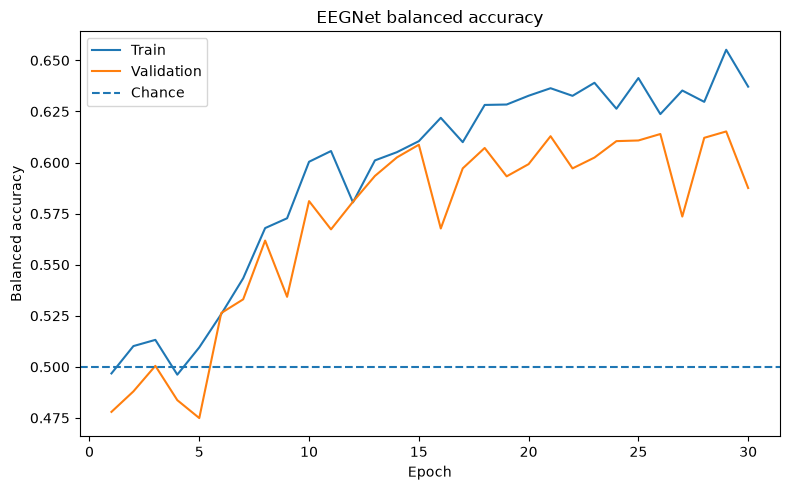

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_ba"],
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_ba"],
    label="Validation"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Chance"
)

plt.xlabel("Epoch")
plt.ylabel("Balanced accuracy")
plt.title("EEGNet balanced accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### EEGNet Loss plot

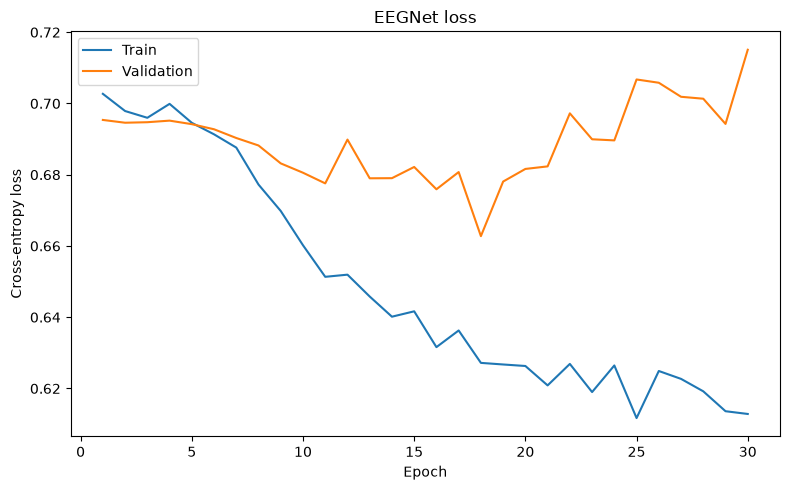

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("EEGNet loss")
plt.legend()
plt.tight_layout()
plt.show()

## Week 10 Summary

This notebook implemented and trained EEGNet for cross-subject motor-imagery classification.

The EEGNet pipeline used the same frozen preprocessing and subject split as the previous CNN baseline:

- 76 training subjects
- 3,423 training trials
- 16 validation subjects
- 718 validation trials
- 17 test subjects kept completely untouched

The model was built and checked stage by stage:

EEG input
→ temporal convolution
→ depthwise spatial convolution
→ batch normalization + ELU
→ average pooling + dropout
→ depthwise temporal convolution
→ pointwise convolution
→ pooling + dropout
→ linear classifier
→ 2 logits

A tiny-batch overfitting test was first used to verify that the complete architecture
could learn. With dropout disabled for the diagnostic test, EEGNet reached 100%
accuracy on the 32 repeated trials with an evaluation loss of approximately
0.0001.

The full model was then trained for 30 epochs with dropout enabled.

Training performance:
- Epoch 1 loss: 0.7027
- Epoch 1 balanced accuracy: 0.497
- Highest training balanced accuracy: 0.655 at epoch 29
- Epoch 30 loss: 0.6128
- Epoch 30 balanced accuracy: 0.637

Validation performance:
- Epoch 1 loss: 0.6954
- Epoch 1 balanced accuracy: 0.478
- Best validation balanced accuracy: 0.615 at epoch 29
- Lowest validation loss: 0.6628 at epoch 18
- Epoch 30 loss: 0.7151
- Epoch 30 balanced accuracy: 0.588

Compared with the CNN baseline, with the best validation balanced accuracy
at 0.528, the EEGNet reached a substantially higher validation
balanced accuracy of 0.615 on the same subject split.

Unlike the baseline CNN, EEGNet did not approach perfect training accuracy. Training and validation balanced
accuracy instead increased together for much of training.

However, validation loss began increasing again during later epochs while
training loss continued decreasing. This suggests that some overfitting still
developed later in training.

The held-out test subjects were not evaluated.